# Transformer-Hybrid (CNN + BiLSTM + Transformer) - Georgia Evaluation

Loads `checkpoints/best_model.pt`, rebuilds the test split and produces the
metrics + figures + XAI in the same style as the other Georgia eval notebooks.


## 1 . Imports & config

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pickle, pathlib
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, multilabel_confusion_matrix, roc_auc_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
sns.set_style('whitegrid')

SEED        = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else
                            'mps'  if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

CLASS_NAMES = ['MI', 'STTC', 'CD', 'HYP']
NUM_CLASSES = 4
NORM_CAP    = 4000
BATCH_SIZE  = 64
THRESHOLD   = 0.5
COLORS      = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
LEAD_NAMES  = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']


Device: cuda


## 2 . Load data & rebuild test split

In [2]:
def load_pkl(p):
    with open(p, 'rb') as f: return pickle.load(f)

DATA_DIR = pathlib.Path('../../GeorgiaECG')
CKPT_DIR = pathlib.Path('checkpoints')

X_all = np.asarray(load_pkl(DATA_DIR/'X_georgia.pickle'), dtype=np.float32)
y_all = np.asarray(load_pkl(DATA_DIR/'y_georgia.pickle'), dtype=np.float32)

rng         = np.random.default_rng(SEED)
norm_idx    = np.where(y_all.sum(1) == 0)[0]
disease_idx = np.where(y_all.sum(1) >  0)[0]
if len(norm_idx) > NORM_CAP:
    norm_idx = rng.choice(norm_idx, NORM_CAP, replace=False)
bal_idx      = np.concatenate([disease_idx, norm_idx])
X_bal, y_bal = X_all[bal_idx], y_all[bal_idx]

norm_col = (y_bal.sum(1) == 0).astype(np.float32)[:, None]
y_strat  = np.concatenate([y_bal, norm_col], axis=1)
msss1    = MultilabelStratifiedShuffleSplit(1, test_size=0.15,  random_state=SEED)
tv_idx, te_idx = next(msss1.split(X_bal, y_strat))
y_tv_str = np.concatenate([y_bal[tv_idx],
                            (y_bal[tv_idx].sum(1)==0).astype(np.float32)[:,None]], axis=1)
msss2    = MultilabelStratifiedShuffleSplit(1, test_size=0.176, random_state=SEED)
tr2, va2 = next(msss2.split(X_bal[tv_idx], y_tv_str))

X_train_s, y_train_s = X_bal[tv_idx][tr2], y_bal[tv_idx][tr2]
X_val_s,   y_val_s   = X_bal[tv_idx][va2], y_bal[tv_idx][va2]
X_test_s,  y_test_s  = X_bal[te_idx],      y_bal[te_idx]
print(f'Train {len(X_train_s)} | Val {len(X_val_s)} | Test {len(X_test_s)}')


Train 7229 | Val 1548 | Test 1567


## 3 . Model - load checkpoint

In [3]:
class CNN_BiLSTM_Transformer(nn.Module):
    """
    CNN + BiLSTM + Transformer Encoder hybrid for 12-lead ECG multi-label
    classification.

    Reference:
      Mehmood et al., "A joint CNN-Bi-LSTM-transformer architecture with SHAP
      explanations for multi-label arrhythmia detection from 12-lead ECGs",
      Nature Scientific Reports, 2026.
      https://www.nature.com/articles/s41598-026-40925-5

    Stage 1 - 1D CNN front-end captures morphological features (P/QRS/T waves)
              from raw multi-lead ECG.
    Stage 2 - 2-layer BiLSTM models local temporal dependencies on the CNN
              token sequence.
    Stage 3 - TransformerEncoder (multi-head self-attention) captures long-range
              beat-to-beat dependencies with learned positional embeddings.
    Stage 4 - Mean-pool over time + linear classification head returning logits.

    Input  : (B, 12, 1000) - 12-lead ECG @ 100 Hz, 10-second window
    Output : (B, n_classes) raw logits (sigmoid applied externally)
    """
    def __init__(self, n_classes=NUM_CLASSES, n_leads=12,
                 d_model=256, lstm_hidden=128, n_heads=8,
                 n_transformer_layers=2, ff_dim=512, dropout=0.2):
        super().__init__()

        # Stage 1 - 1D CNN front-end
        self.cnn = nn.Sequential(
            nn.Conv1d(n_leads,  64, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64),  nn.GELU(), nn.MaxPool1d(2),
            nn.Conv1d(64,      128, kernel_size=11, stride=1, padding=5, bias=False),
            nn.BatchNorm1d(128), nn.GELU(), nn.MaxPool1d(2),
            nn.Conv1d(128,     192, kernel_size=7,  stride=1, padding=3, bias=False),
            nn.BatchNorm1d(192), nn.GELU(), nn.MaxPool1d(2),
            nn.Conv1d(192, d_model, kernel_size=5,  stride=1, padding=2, bias=False),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

        # Stage 2 - BiLSTM temporal encoder
        self.bilstm = nn.LSTM(
            input_size=d_model, hidden_size=lstm_hidden, num_layers=2,
            batch_first=True, bidirectional=True, dropout=dropout,
        )
        # BiLSTM output = 2 * lstm_hidden = d_model

        # Stage 3 - Transformer encoder with learned positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, 512, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation='gelu', batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)
        self.norm = nn.LayerNorm(d_model)

        # Stage 4 - classifier
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x):                     # x : (B, 12, 1000)
        feat = self.cnn(x)                    # (B, 256, T')
        feat = feat.permute(0, 2, 1)          # (B, T', 256)

        lstm_out, _ = self.bilstm(feat)       # (B, T', 256)

        T = lstm_out.size(1)
        out = lstm_out + self.pos_embed[:, :T, :]
        out = self.transformer(out)           # (B, T', 256)
        out = self.norm(out)

        pooled = out.mean(dim=1)              # (B, 256)
        return self.classifier(self.dropout(pooled))   # logits

model = CNN_BiLSTM_Transformer().to(DEVICE)
ckpt  = torch.load(CKPT_DIR/'best_model.pt', map_location=DEVICE)
model.load_state_dict(ckpt); model.eval()
print(f'Loaded checkpoint  |  params: {sum(p.numel() for p in model.parameters()):,}')


Loaded checkpoint  |  params: 2,498,052


## 4 . Inference on val & test

In [4]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float(); self.y = torch.from_numpy(y).float()
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
val_loader = DataLoader(ECGDataset(X_val_s,  y_val_s),  shuffle=False, **kw)
te_loader  = DataLoader(ECGDataset(X_test_s, y_test_s), shuffle=False, **kw)

def infer(loader, mdl):
    mdl.eval(); probs, tgts = [], []
    with torch.no_grad():
        for xb, yb in loader:
            probs.append(torch.sigmoid(mdl(xb.to(DEVICE))).cpu().numpy())
            tgts.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(tgts)

val_probs,  val_tgts  = infer(val_loader, model)
test_probs, test_tgts = infer(te_loader,  model)
print(f'Val {val_probs.shape}  Test {test_probs.shape}')


Val (1548, 4)  Test (1567, 4)


## 5 . Threshold tuning (val set - no test leakage)

In [5]:
def compute_metrics(probs, targets, threshold=0.5):
    thr = np.array(threshold) if not np.isscalar(threshold) else threshold
    preds = (probs >= thr).astype(int)
    mcm   = multilabel_confusion_matrix(targets.astype(int), preds)
    res   = {}
    for i, cls in enumerate(CLASS_NAMES):
        tn, fp, fn, tp = mcm[i].ravel()
        res[cls] = dict(
            sensitivity = tp/(tp+fn+1e-8),
            specificity = tn/(tn+fp+1e-8),
            accuracy    = (tp+tn)/(tp+tn+fp+fn+1e-8),
            f1          = 2*tp/(2*tp+fp+fn+1e-8),
        )
    for m in ('sensitivity','specificity','accuracy','f1'):
        res[f'macro_{m}'] = np.mean([res[c][m] for c in CLASS_NAMES])
    return res

def print_metrics(m, label=''):
    if label: print(f"\n{'-'*55}\n  {label}\n{'-'*55}")
    print(f"{'Class':<6} {'Sensitivity':>12} {'Specificity':>12} {'Accuracy':>10} {'F1':>8}")
    print('-'*52)
    for cls in CLASS_NAMES:
        print(f"{cls:<6} {m[cls]['sensitivity']:>12.4f} {m[cls]['specificity']:>12.4f} "
              f"{m[cls]['accuracy']:>10.4f} {m[cls]['f1']:>8.4f}")
    print('-'*52)
    print(f"{'Macro':<6} {m['macro_sensitivity']:>12.4f} {m['macro_specificity']:>12.4f} "
          f"{m['macro_accuracy']:>10.4f} {m['macro_f1']:>8.4f}")
    try:
        auc = roc_auc_score(test_tgts, test_probs, average='macro')
        print(f'  Macro AUC: {auc:.4f}')
    except Exception:
        pass


In [6]:
grid = np.arange(0.05, 0.95, 0.01)
best_t, curves = {}, {}
print('Threshold tuning on val set (no test leakage):')
print(f"{'Class':<6} {'Best t':>8} {'F1@0.5':>9} {'F1@best':>9}")
print('-'*36)
for i, cls in enumerate(CLASS_NAMES):
    f1s   = [f1_score(val_tgts[:,i], (val_probs[:,i]>=t).astype(int), zero_division=0) for t in grid]
    bt    = grid[np.argmax(f1s)]
    f50   = f1_score(val_tgts[:,i], (val_probs[:,i]>=0.5).astype(int), zero_division=0)
    best_t[cls] = bt; curves[cls] = f1s
    print(f"{cls:<6} {bt:>8.2f} {f50:>9.4f} {max(f1s):>9.4f}")

tuned_arr  = np.array([best_t[c] for c in CLASS_NAMES])
test_m_def = compute_metrics(test_probs, test_tgts, 0.5)
test_m_tun = compute_metrics(test_probs, test_tgts, tuned_arr)

print('\nTest - default vs tuned:')
print(f"{'Class':<6} {'F1@0.5':>8} {'F1@tuned':>10} {'d':>7}")
print('-'*30)
for cls in CLASS_NAMES:
    d = test_m_tun[cls]['f1'] - test_m_def[cls]['f1']
    print(f"{cls:<6} {test_m_def[cls]['f1']:>8.4f} {test_m_tun[cls]['f1']:>10.4f} {d:>+6.4f}")
d_mac = test_m_tun['macro_f1'] - test_m_def['macro_f1']
print(f"{'Macro':<6} {test_m_def['macro_f1']:>8.4f} {test_m_tun['macro_f1']:>10.4f} {d_mac:>+6.4f}")


Threshold tuning on val set (no test leakage):
Class    Best t    F1@0.5   F1@best
------------------------------------
MI         0.45    0.4333    0.4395
STTC       0.58    0.6741    0.6785
CD         0.65    0.6831    0.6951
HYP        0.42    0.5935    0.6111

Test - default vs tuned:
Class    F1@0.5   F1@tuned       d
------------------------------
MI       0.4197     0.4125 -0.0072
STTC     0.6828     0.6728 -0.0100
CD       0.6719     0.6701 -0.0017
HYP      0.6205     0.6185 -0.0020
Macro    0.5987     0.5935 -0.0052


## 6 . Metrics & visualisations


-------------------------------------------------------
  Test - tuned thresholds
-------------------------------------------------------
Class   Sensitivity  Specificity   Accuracy       F1
----------------------------------------------------
MI           0.5238       0.9112     0.8800   0.4125
STTC         0.7194       0.7649     0.7486   0.6728
CD           0.6885       0.7934     0.7556   0.6701
HYP          0.8299       0.4872     0.6158   0.6185
----------------------------------------------------
Macro        0.6904       0.7392     0.7500   0.5935
  Macro AUC: 0.8078


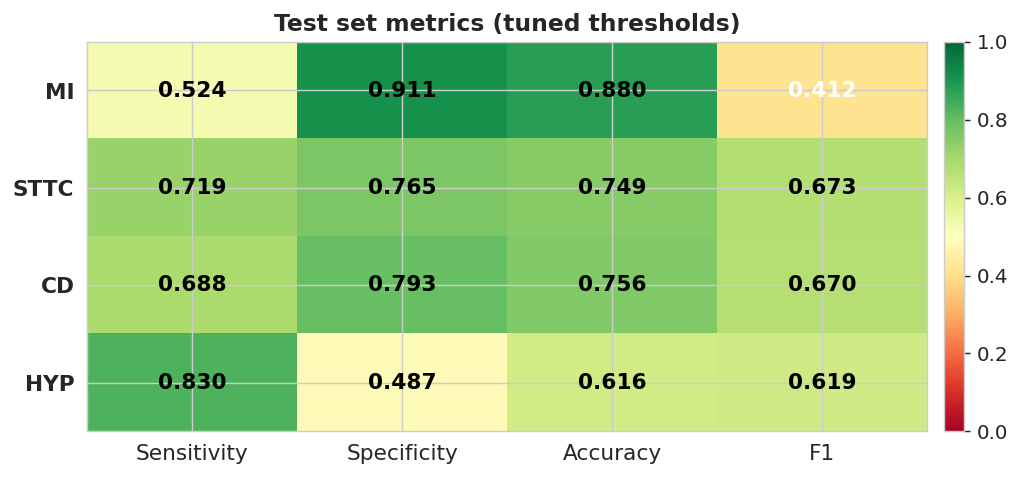

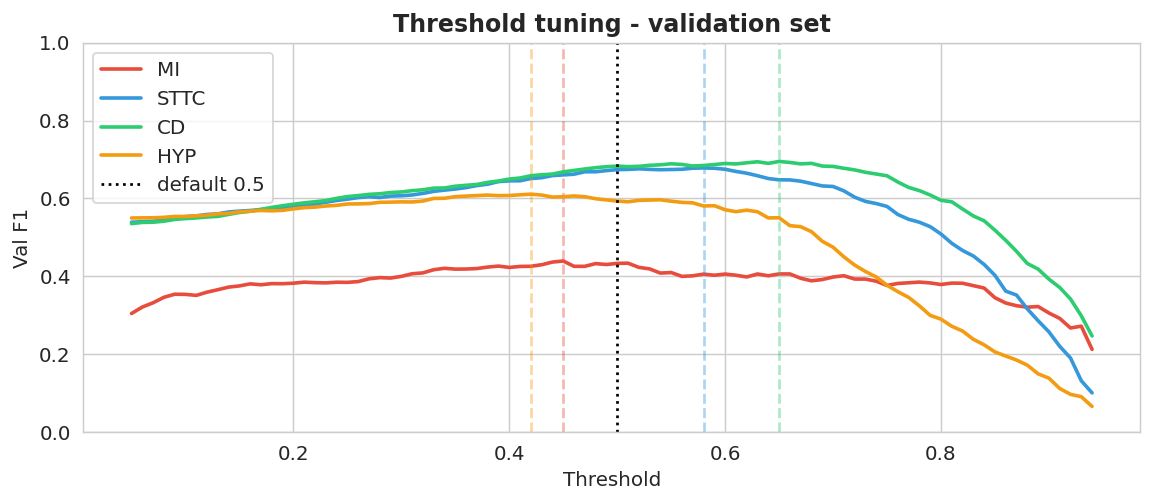

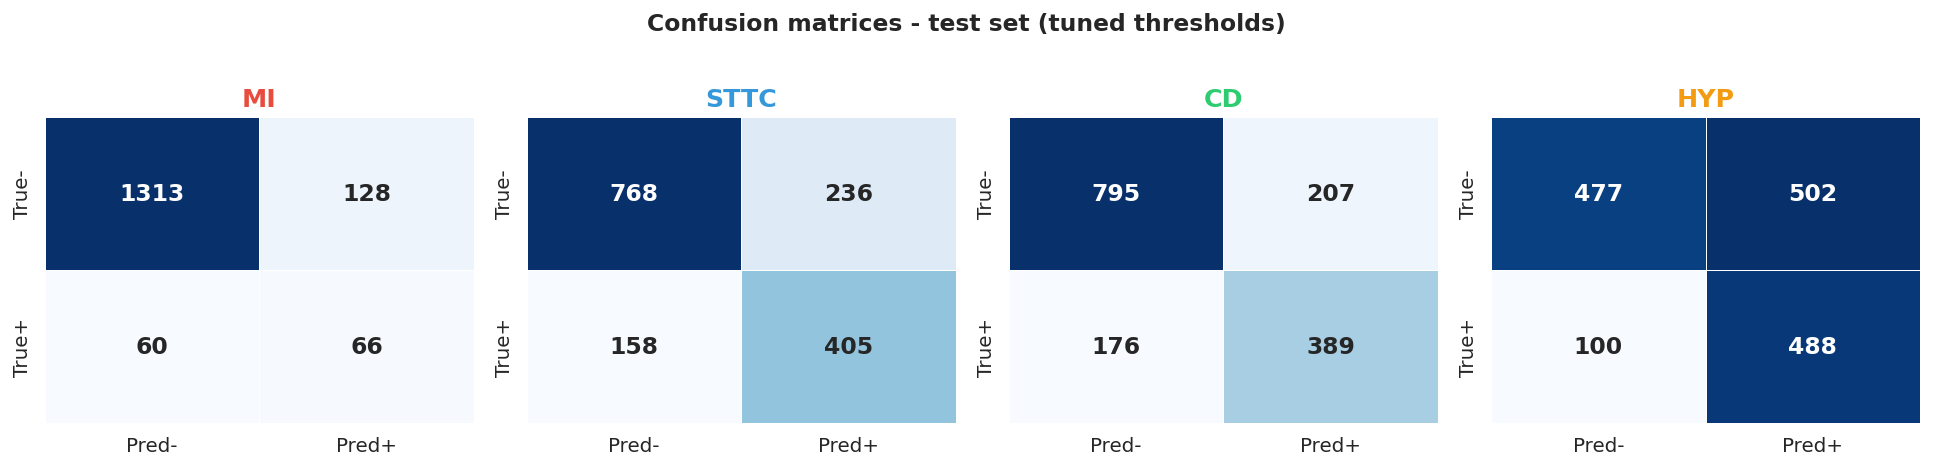

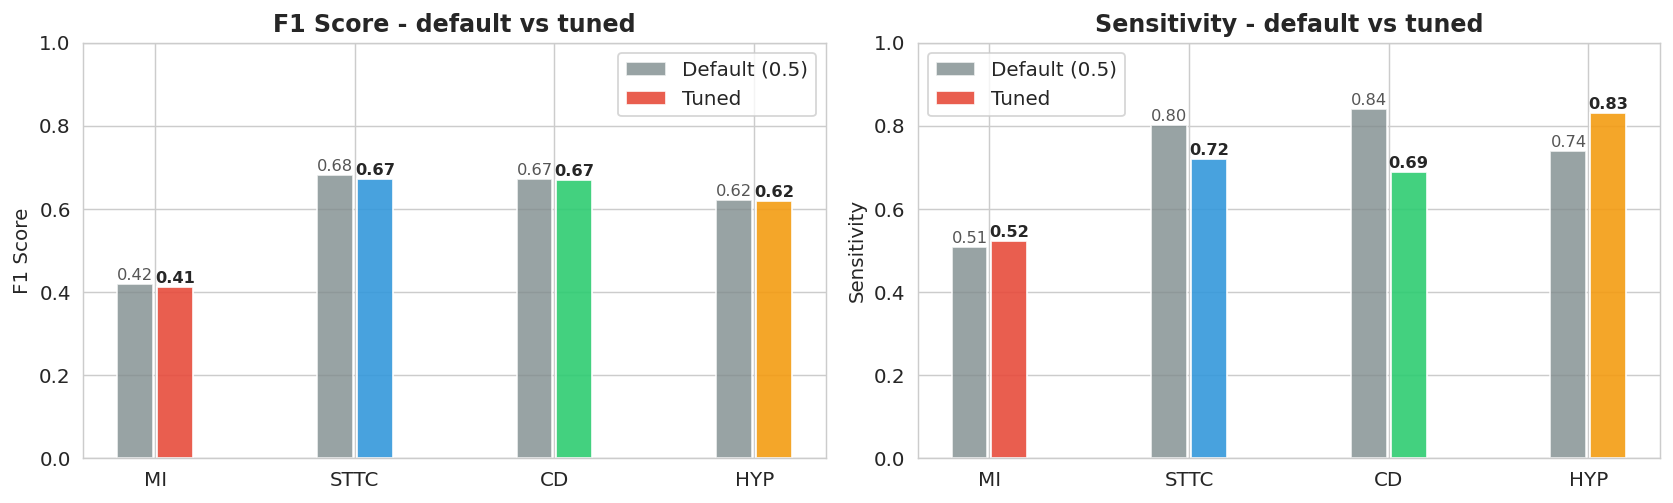

In [7]:
print_metrics(test_m_tun, 'Test - tuned thresholds')

# 1. Metric heatmap
keys   = ['sensitivity','specificity','accuracy','f1']
labels = ['Sensitivity','Specificity','Accuracy','F1']
data   = np.array([[test_m_tun[c][k] for k in keys] for c in CLASS_NAMES])

fig, ax = plt.subplots(figsize=(8, 3.8))
im = ax.imshow(data, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=12)
ax.set_yticks(range(4)); ax.set_yticklabels(CLASS_NAMES, fontsize=12, fontweight='bold')
for i in range(4):
    for j in range(4):
        v = data[i,j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                fontsize=12, fontweight='bold', color='white' if v < 0.45 else 'black')
ax.set_title('Test set metrics (tuned thresholds)', fontweight='bold', fontsize=13)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
plt.tight_layout(); plt.savefig(CKPT_DIR/'metrics_heatmap.png', bbox_inches='tight'); plt.show()

# 2. Threshold curves
fig, ax = plt.subplots(figsize=(9, 4))
for cls, col in zip(CLASS_NAMES, COLORS):
    ax.plot(grid, curves[cls], color=col, linewidth=2, label=cls)
    ax.axvline(best_t[cls], color=col, linestyle='--', alpha=0.4)
ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, label='default 0.5')
ax.set_xlabel('Threshold'); ax.set_ylabel('Val F1'); ax.set_ylim(0, 1)
ax.set_title('Threshold tuning - validation set', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig(CKPT_DIR/'threshold_curves.png', bbox_inches='tight'); plt.show()

# 3. Confusion matrices
preds_tuned = (test_probs >= tuned_arr).astype(int)
mcm = multilabel_confusion_matrix(test_tgts.astype(int), preds_tuned)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for i, (ax, cls, col) in enumerate(zip(axes, CLASS_NAMES, COLORS)):
    sns.heatmap(mcm[i], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                linewidths=0.5, annot_kws={'size': 13, 'weight': 'bold'},
                xticklabels=['Pred-', 'Pred+'], yticklabels=['True-', 'True+'])
    ax.set_title(cls, fontweight='bold', color=col, fontsize=14)
plt.suptitle('Confusion matrices - test set (tuned thresholds)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(CKPT_DIR/'confusion_matrices.png', bbox_inches='tight'); plt.show()

# 4. F1 & Sensitivity bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(4); w = 0.2
for ax, (metric, label) in zip(axes, [('f1', 'F1 Score'), ('sensitivity', 'Sensitivity')]):
    vd = [test_m_def[c][metric] for c in CLASS_NAMES]
    vt = [test_m_tun[c][metric] for c in CLASS_NAMES]
    ax.bar(x - w/2, vd, w*0.9, label='Default (0.5)', color='#7f8c8d', alpha=0.8)
    ax.bar(x + w/2, vt, w*0.9, label='Tuned',         color=COLORS,    alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
    ax.set_ylim(0, 1); ax.set_ylabel(label)
    ax.set_title(f'{label} - default vs tuned', fontweight='bold')
    ax.legend()
    for xi, (a, b) in enumerate(zip(vd, vt)):
        ax.text(xi-w/2, a+0.01, f'{a:.2f}', ha='center', fontsize=9, color='#555')
        ax.text(xi+w/2, b+0.01, f'{b:.2f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.savefig(CKPT_DIR/'bar_metrics.png', bbox_inches='tight'); plt.show()


## 7 . XAI

GradCAM1D target: Conv1d(192, 256, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)


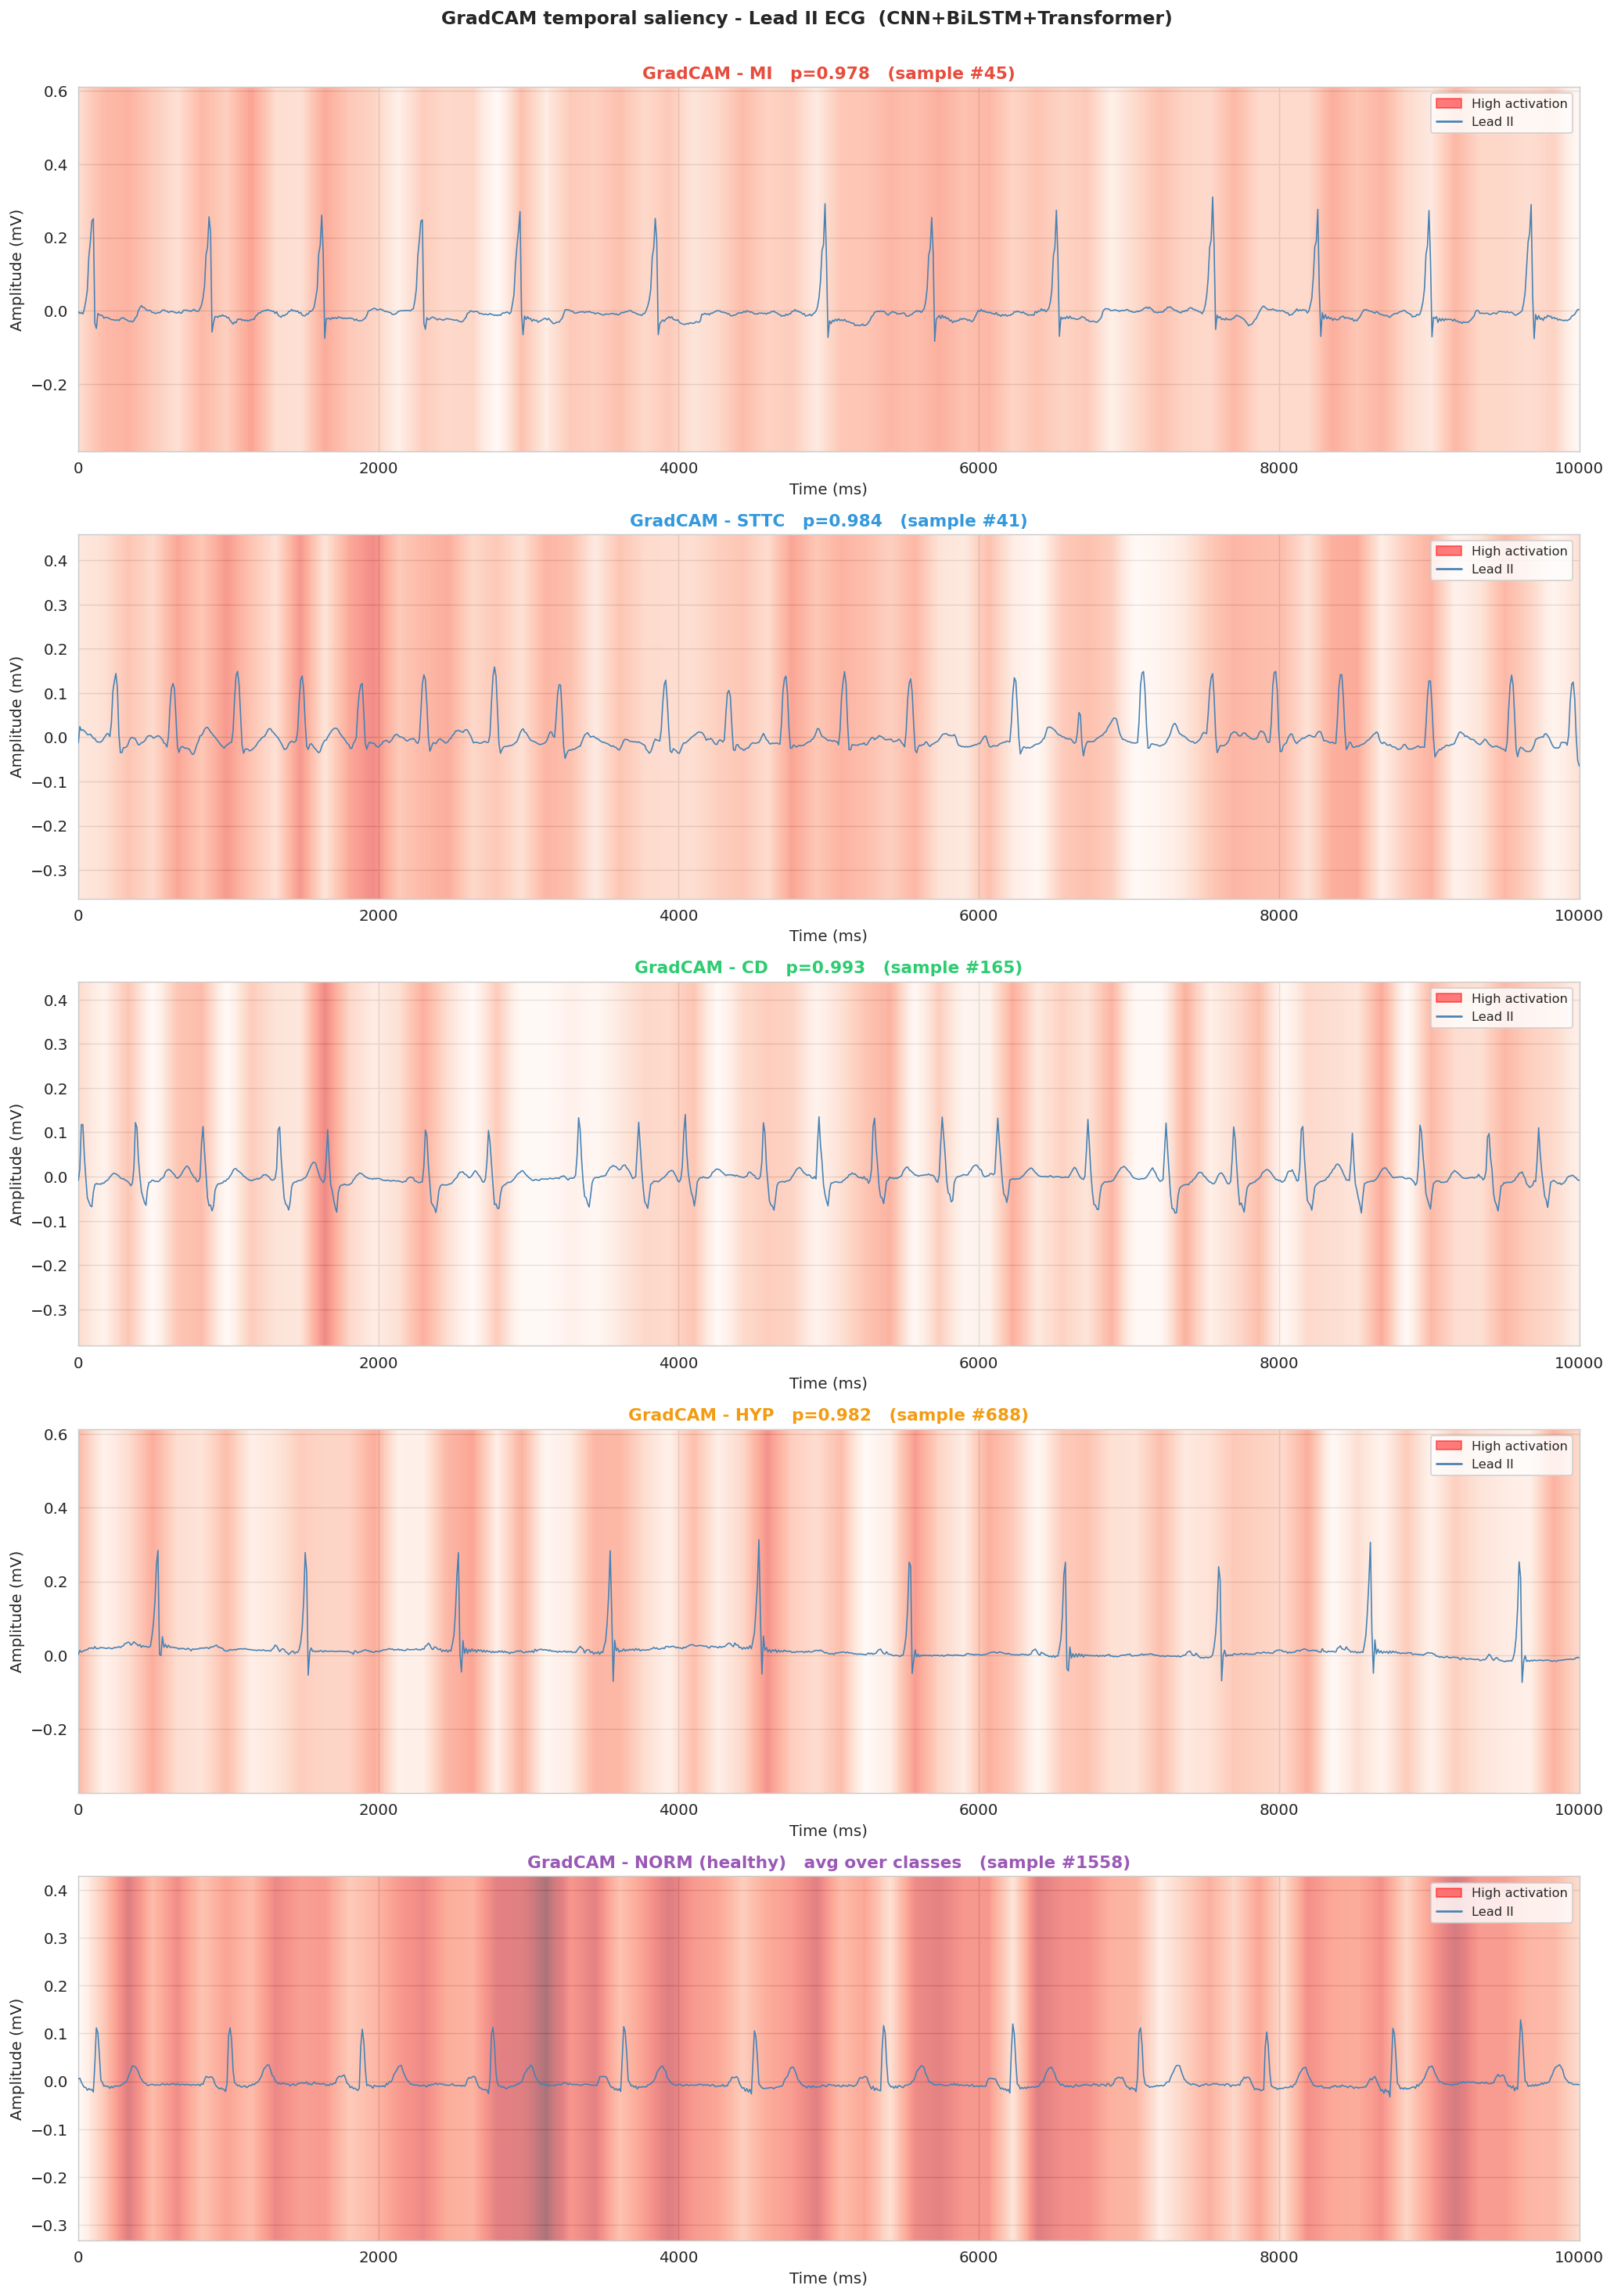

Computing IG for MI (sample #45) ...


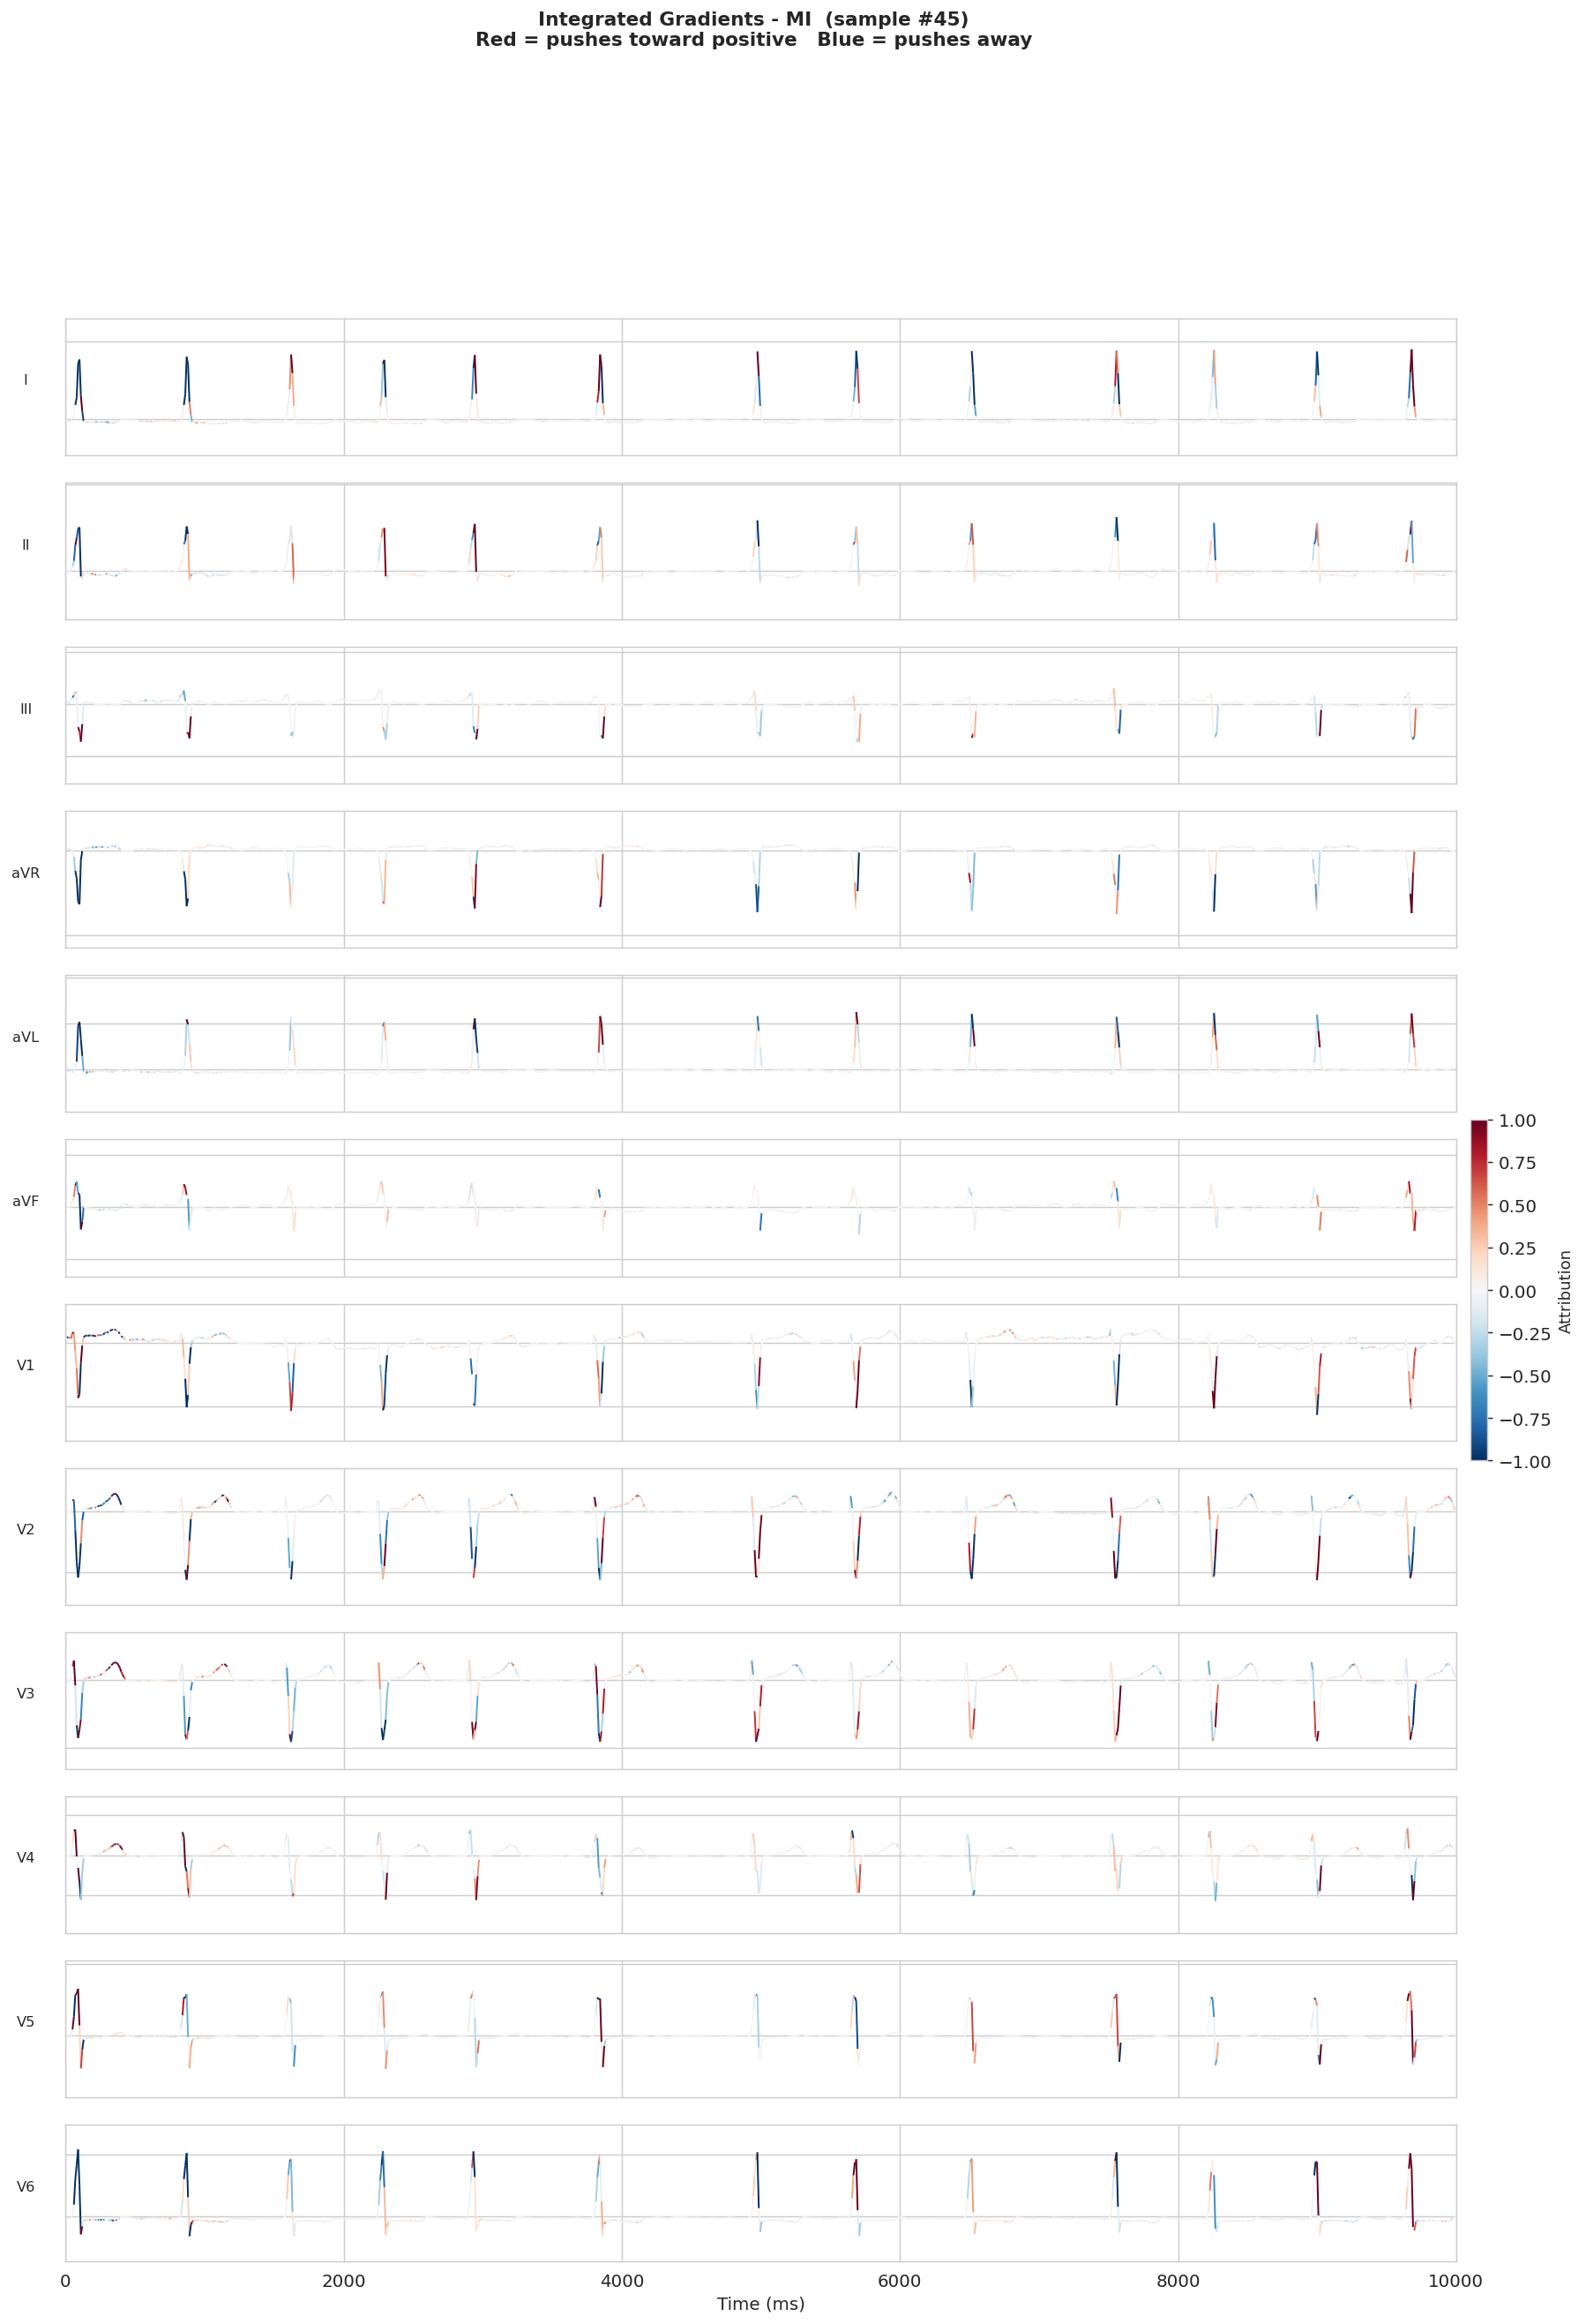

Lead importance MI: 15 samples ...
Lead importance STTC: 15 samples ...
Lead importance CD: 15 samples ...
Lead importance HYP: 15 samples ...


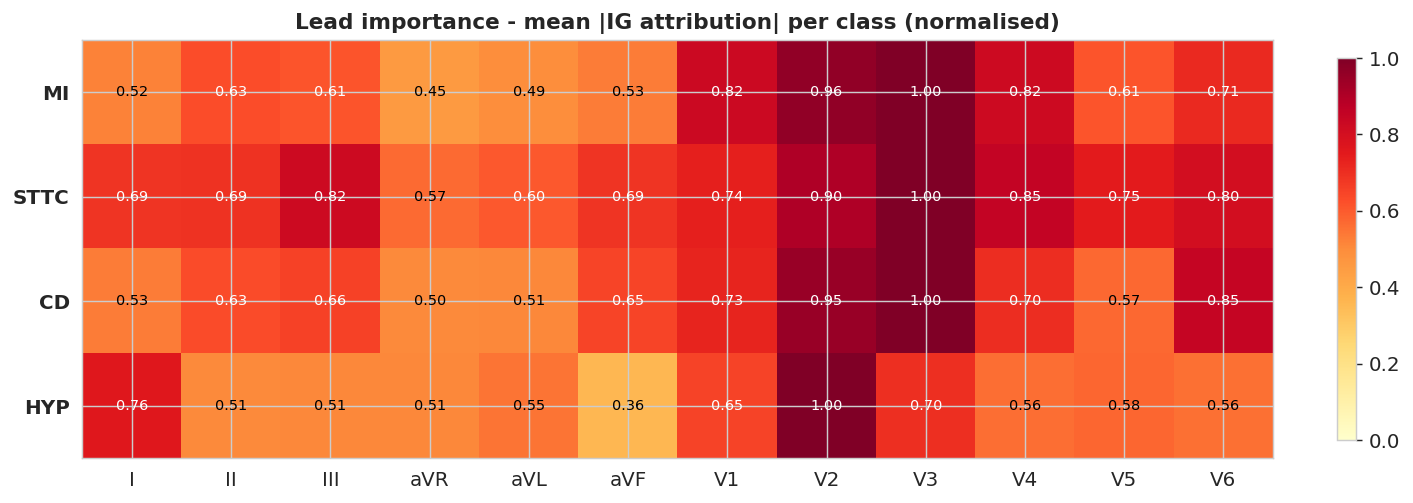

In [8]:
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches

def get_sample(ci, targets, probs):
    mask = targets[:, ci] == 1
    if not mask.any(): mask = np.ones(len(targets), bool)
    return np.argmax(probs[:, ci] * mask)

def integrated_gradients(mdl, x, ci, n_steps=50):
    baseline = torch.zeros_like(x).to(DEVICE)
    x        = x.to(DEVICE)
    alphas   = torch.linspace(0, 1, n_steps).to(DEVICE)
    grads    = []
    mdl.train()
    for a in alphas:
        inp = (baseline + a * (x - baseline)).requires_grad_(True)
        mdl(inp)[0, ci].backward(); mdl.zero_grad()
        grads.append(inp.grad.squeeze(0).cpu())
    mdl.eval()
    avg_g = torch.stack(grads).mean(0)
    return ((x.squeeze(0).cpu() - baseline.squeeze(0).cpu()) * avg_g).numpy()

class GradCAM1D:
    def __init__(self, mdl, layer):
        self.mdl, self.act, self.grad = mdl, None, None
        self._fh = layer.register_forward_hook(lambda m,i,o: setattr(self, 'act', o.detach()))
        self._bh = layer.register_full_backward_hook(lambda m,gi,go: setattr(self, 'grad', go[0].detach()))
    def generate(self, x, ci):
        was = self.mdl.training; self.mdl.train()
        x   = x.requires_grad_(True)
        self.mdl(x)[0, ci].backward(); self.mdl.zero_grad()
        if not was: self.mdl.eval()
        w   = self.grad.mean(-1, keepdim=True)
        cam = torch.relu((w * self.act).sum(1)).squeeze().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    def remove(self): self._fh.remove(); self._bh.remove()

def find_last_conv1d(mdl):
    last = None
    for m in mdl.modules():
        if isinstance(m, nn.Conv1d): last = m
    return last

target_layer = find_last_conv1d(model)
print('GradCAM1D target:', target_layer)
grad_cam = GradCAM1D(model, target_layer)
TIME_MS  = np.linspace(0, 10000, 1000)

# XAI 1 - GradCAM on Lead II, one panel per class + NORM
groups = [(cls, ci, get_sample(ci, test_tgts, test_probs)) for ci, cls in enumerate(CLASS_NAMES)]
norm_mask = (test_tgts.sum(1) == 0) & ((test_probs >= 0.5).sum(1) == 0)
if norm_mask.any():
    ni = np.where(norm_mask)[0][np.argmax(1 - test_probs[norm_mask].max(1))]
    groups.append(('NORM (healthy)', -1, ni))

pcols = COLORS + ['#9b59b6']
fig, axes = plt.subplots(len(groups), 1, figsize=(16, 4.5 * len(groups)))
if len(groups) == 1: axes = [axes]
for (cls, ci, idx), ax, col in zip(groups, axes, pcols):
    sig = X_test_s[idx]
    xt  = torch.tensor(sig[None], dtype=torch.float32).to(DEVICE)
    if ci >= 0:
        cam = grad_cam.generate(xt, ci)
    else:
        cams = [grad_cam.generate(xt, c) for c in range(NUM_CLASSES)]
        cam  = np.mean(cams, 0); cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
    cam_up = np.interp(np.linspace(0,1,1000), np.linspace(0,1,len(cam)), cam)
    sig2   = sig[1]
    yl, yh = sig2.min()-0.3, sig2.max()+0.3
    ax.pcolormesh(np.linspace(TIME_MS[0],TIME_MS[-1],1001), [yl,yh],
                  cam_up[None], cmap='Reds', alpha=0.55, vmin=0, vmax=1, shading='flat')
    ax.plot(TIME_MS, sig2, color='steelblue', linewidth=0.9, zorder=3)
    lbl = 'avg over classes' if ci < 0 else f'p={test_probs[idx,ci]:.3f}'
    ax.set_title(f'GradCAM - {cls}   {lbl}   (sample #{idx})',
                 fontweight='bold', color=col, fontsize=12)
    ax.set_xlabel('Time (ms)'); ax.set_ylabel('Amplitude (mV)')
    ax.legend([mpatches.Patch(color='red', alpha=0.5), plt.Line2D([],[],color='steelblue')],
              ['High activation', 'Lead II'], loc='upper right', fontsize=9)
plt.suptitle('GradCAM temporal saliency - Lead II ECG  (CNN+BiLSTM+Transformer)',
             fontweight='bold', fontsize=13, y=1.002)
plt.tight_layout(); plt.savefig(CKPT_DIR/'xai_gradcam1d.png', bbox_inches='tight'); plt.show()
grad_cam.remove()

# XAI 2 - Integrated Gradients on all 12 leads (MI sample)
demo_ci  = 0
demo_idx = get_sample(demo_ci, test_tgts, test_probs)
xt       = torch.tensor(X_test_s[demo_idx][None], dtype=torch.float32)
print(f'Computing IG for {CLASS_NAMES[demo_ci]} (sample #{demo_idx}) ...')
attr     = integrated_gradients(model, xt, demo_ci)

fig, axes = plt.subplots(12, 1, figsize=(16, 22), sharex=True)
for li, (ax, lname) in enumerate(zip(axes, LEAD_NAMES)):
    a   = attr[li]; sig = X_test_s[demo_idx][li]
    pts = np.array([TIME_MS, sig]).T.reshape(-1,1,2)
    segs= np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc  = LineCollection(segs, cmap='RdBu_r', norm=plt.Normalize(-1,1), linewidth=1.1)
    lc.set_array(a)
    ax.add_collection(lc)
    ax.set_xlim(TIME_MS[0], TIME_MS[-1])
    ax.set_ylim(sig.min()-0.2, sig.max()+0.2)
    ax.set_ylabel(lname, fontsize=9, rotation=0, labelpad=25)
    ax.tick_params(left=False, labelleft=False)
axes[-1].set_xlabel('Time (ms)')
plt.colorbar(lc, ax=axes, fraction=0.012, pad=0.01).set_label('Attribution', fontsize=10)
plt.suptitle(f'Integrated Gradients - {CLASS_NAMES[demo_ci]}  (sample #{demo_idx})\n'
             'Red = pushes toward positive   Blue = pushes away',
             fontweight='bold', fontsize=12, y=1.002)
plt.savefig(CKPT_DIR/'xai_ig_leads.png', bbox_inches='tight'); plt.show()

# XAI 3 - Lead importance (mean |IG| per class)
N_EXP = 15
lead_imp = np.zeros((NUM_CLASSES, 12))
for ci, cls in enumerate(CLASS_NAMES):
    idxs = np.where((test_tgts[:,ci]==1) & (test_probs[:,ci]>=0.5))[0][:N_EXP]
    if not len(idxs): continue
    print(f'Lead importance {cls}: {len(idxs)} samples ...')
    attrs = []
    for idx in idxs:
        a = integrated_gradients(model, torch.tensor(X_test_s[idx][None],dtype=torch.float32), ci, n_steps=30)
        attrs.append(np.abs(a).mean(1))
    lead_imp[ci] = np.mean(attrs, 0)
lead_imp_n = lead_imp / (lead_imp.max(1, keepdims=True) + 1e-8)

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(lead_imp_n, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(12)); ax.set_xticklabels(LEAD_NAMES, fontsize=11)
ax.set_yticks(range(4));  ax.set_yticklabels(CLASS_NAMES, fontsize=11, fontweight='bold')
for i in range(4):
    for j in range(12):
        v = lead_imp_n[i,j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=8, color='white' if v > 0.6 else 'black')
ax.set_title('Lead importance - mean |IG attribution| per class (normalised)',
             fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.015)
plt.tight_layout(); plt.savefig(CKPT_DIR/'xai_lead_importance.png', bbox_inches='tight'); plt.show()


## 8 . Summary

In [9]:
print('='*60)
print(f'  SUMMARY  |  {model.__class__.__name__}  |  Georgia')
print('='*60)
print_metrics(test_m_tun, 'Test set - tuned thresholds')
print()
for f in sorted(CKPT_DIR.iterdir()):
    if f.is_file(): print(f'  {f.name:<45} {f.stat().st_size/1024:6.1f} KB')


  SUMMARY  |  CNN_BiLSTM_Transformer  |  Georgia

-------------------------------------------------------
  Test set - tuned thresholds
-------------------------------------------------------
Class   Sensitivity  Specificity   Accuracy       F1
----------------------------------------------------
MI           0.5238       0.9112     0.8800   0.4125
STTC         0.7194       0.7649     0.7486   0.6728
CD           0.6885       0.7934     0.7556   0.6701
HYP          0.8299       0.4872     0.6158   0.6185
----------------------------------------------------
Macro        0.6904       0.7392     0.7500   0.5935
  Macro AUC: 0.8078

  bar_metrics.png                                 48.3 KB
  best_model.pt                                 9783.9 KB
  confusion_matrices.png                          41.8 KB
  metrics_heatmap.png                             54.4 KB
  threshold_curves.png                            72.0 KB
  training_curves.png                             43.2 KB
  xai_gradcam1d